<h1 style="text-align:center; color:green;">Big Data Analysis Final Report</h1>

<p><b>Name:</b> Viraj Jadhav</p>
<p><b>College:</b> D.Y. Patil International University</p>
<p><b>PRN:</b> 20240802660</p>

<h2>The Problem: "Eco-Stream" E-Commerce Optimization</h2>

<p>
"Eco-Stream" is a growing online marketplace for sustainable goods. The management team is struggling with 
<b>Data Silos</b> — marketing data, sales data, and website logs are all in different places. 
They need a unified system to understand customer behavior and predict future inventory needs.
</p>

<h2>Phase 1: Engineering & Lifecycle</h2>

<h3>Suggestions for Data Ingestion</h3>

<p>
In Eco-Stream, the main issue is that data is scattered in different places, so we need a proper ingestion system.
We can use <b>Batch Processing (Hadoop)</b> for weekly reports and historical analysis, and 
<b>Stream Processing (Kafka)</b> for real-time updates like live orders and inventory.
</p>

<p>
The best approach is a <b>hybrid system</b> that combines both for speed and detailed insights.
</p>

<h3>Suggestions for ETL</h3>

<p>
ELT (Extract, Load, Transform) is better than ETL for modern cloud systems like BigQuery.
In ELT, raw data is first stored and then transformed later.
</p>

<p>
This makes the system more scalable, flexible, and faster compared to traditional ETL.
</p>

<h3>Data Quality Methodology</h3>

<p>
To ensure data quality, validation rules should be applied:
</p>

<ul>
<li>Price must be numeric</li>
<li>Price should not be negative</li>
<li>Important fields must not be empty</li>
</ul>

<p>
This can be implemented using schema validation and automated scripts.
</p>

<h2>Phase 2: Analytics & Strategy</h2>

<h3>Cart Abandonment Rate</h3>

<p>
Cart abandonment rate shows how many users add items to the cart but do not complete the purchase.
It helps identify issues in the checkout process and improve conversion rates.
</p>

<h3>Cart Abandonment Rate Formula</h3>

<p>This formula helps calculate the percentage of users who add items to the cart but do not complete the purchase.</p>

$$
Cart\ Abandonment\ Rate = \frac{(Carts\ Created - Completed\ Purchases)}{Carts\ Created} \times 100
$$

In [10]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
#Load Dataset
df = pd.read_csv("Sales_April_2019.csv")
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


In [12]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18383 entries, 0 to 18382
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Order ID          18324 non-null  object
 1   Product           18324 non-null  object
 2   Quantity Ordered  18324 non-null  object
 3   Price Each        18324 non-null  object
 4   Order Date        18324 non-null  object
 5   Purchase Address  18324 non-null  object
dtypes: object(6)
memory usage: 861.8+ KB


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
count,18324,18324,18324,18324,18324,18324
unique,17538,20,8,19,13584,17120
top,Order ID,Lightning Charging Cable,1,14.95,Order Date,Purchase Address
freq,35,2201,16558,2201,35,35


In [13]:
df = df.dropna() #Remove NaN values

In [14]:
df = df.drop_duplicates() #Remove duplicates

In [15]:
df

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001"
...,...,...,...,...,...,...
18378,194090,Google Phone,1,600,04/08/19 17:11,"177 Jackson St, Los Angeles, CA 90001"
18379,194091,AA Batteries (4-pack),1,3.84,04/15/19 16:02,"311 Forest St, Austin, TX 73301"
18380,194092,AAA Batteries (4-pack),2,2.99,04/28/19 14:36,"347 Sunset St, San Francisco, CA 94016"
18381,194093,AA Batteries (4-pack),1,3.84,04/14/19 15:09,"835 Lake St, Portland, OR 97035"


In [16]:
df['Quantity Ordered'] = pd.to_numeric(df['Quantity Ordered'], errors='coerce')
df['Price Each'] = pd.to_numeric(df['Price Each'], errors='coerce')

In [17]:
df['Sales'] = df['Quantity Ordered'] * df['Price Each']
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Sales
0,176558,USB-C Charging Cable,2.0,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",23.90
2,176559,Bose SoundSport Headphones,1.0,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",99.99
3,176560,Google Phone,1.0,600.00,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",600.00
4,176560,Wired Headphones,1.0,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",11.99
5,176561,Wired Headphones,1.0,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",11.99


In [18]:
df = df[df['Order Date'] != 'Order Date'].copy()

df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

df = df.dropna(subset=['Order Date'])

df['Month'] = df['Order Date'].dt.month

C:\Users\viraj\AppData\Local\Temp\ipykernel_13748\1943466255.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')


In [19]:
correlation = df[['Quantity Ordered', 'Price Each', 'Sales']].corr()
print(correlation)

                  Quantity Ordered  Price Each     Sales
Quantity Ordered          1.000000   -0.150590 -0.140174
Price Each               -0.150590    1.000000  0.997985
Sales                    -0.140174    0.997985  1.000000


<h3>Visualization</h3>

<p>
A dashboard can be created using <b>Power BI</b> to visualize sales trends over time.
This helps management make better data-driven decisions.
</p>

<h3 style="text-align:center;">Sales Dashboard</h3>

<p align="center">
  <img src="Power_BI_Data_Analysis.jpeg" width="1300">
</p>

<h2>Phase 3: Advanced Analytics & Implementation</h2>

<h3>Build a Model (Regression)</h3>

<p>
To predict next month's sales, we can use <b>Supervised Learning (Regression)</b>.
By training a regression model on historical sales data, the system can identify trends and patterns.
</p>

<p>
This helps Eco-Stream forecast future demand and manage inventory efficiently.
</p>

C:\Users\viraj\AppData\Local\Temp\ipykernel_13748\1149559717.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')


   Day      Sales
0    1  118086.63
1    2  104496.71
2    3  113611.75
3    4  116214.99
4    5  114012.88
Predicted Sales for next day: 117583.96374712646


C:\Users\viraj\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


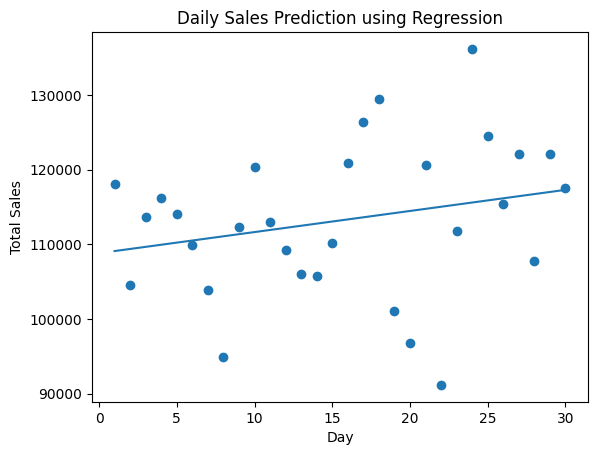

In [39]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("Sales_April_2019.csv")

# ------------------ DATA CLEANING ------------------

df = df[df['Order Date'] != 'Order Date']
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df = df.dropna(subset=['Order Date'])

# Extract day
df['Day'] = df['Order Date'].dt.day

# Convert numeric
df['Quantity Ordered'] = pd.to_numeric(df['Quantity Ordered'], errors='coerce')
df['Price Each'] = pd.to_numeric(df['Price Each'], errors='coerce')

# Create Sales
df['Sales'] = df['Quantity Ordered'] * df['Price Each']

df = df.dropna(subset=['Sales'])

# ------------------ GROUPING (IMPORTANT FIX) ------------------

# Total sales per day
daily_sales = df.groupby('Day')['Sales'].sum().reset_index()

print(daily_sales.head())

# ------------------ MODEL ------------------

X = daily_sales[['Day']]
y = daily_sales['Sales']

model = LinearRegression()
model.fit(X, y)

# Predict next day
prediction = model.predict([[31]])
print("Predicted Sales for next day:", prediction[0])

# ------------------ VISUALIZATION ------------------

plt.scatter(X, y)
plt.plot(X, model.predict(X))
plt.xlabel("Day")
plt.ylabel("Total Sales")
plt.title("Daily Sales Prediction using Regression")
plt.show()

<h3>Sentiment Analysis (NLP)</h3>

<p>
Natural Language Processing (NLP) can be used to analyze customer reviews.
By classifying reviews as positive, negative, or neutral, we can understand customer satisfaction.
</p>

<p>
This helps Eco-Stream improve product quality and customer experience.
</p>

In [36]:
import pandas as pd

# Load dataset
df = pd.read_csv("zomato.csv", encoding='latin-1')
# ------------------ USE RATING TEXT ------------------

df = df[['Rating text']].dropna()

# ------------------ SENTIMENT LOGIC ------------------

def get_sentiment(text):
    text = text.lower()
    
    if text in ['excellent', 'very good', 'good']:
        return "Positive"
    elif text in ['average']:
        return "Neutral"
    else:
        return "Negative"

# Apply sentiment
df['Sentiment'] = df['Rating text'].apply(get_sentiment)

# ------------------ RESULT ------------------

print(df['Sentiment'].value_counts())

Sentiment
Neutral     3737
Positive    3480
Negative    2334
Name: count, dtype: int64


<h3>Sentiment Analysis Result</h3>

<p>
Since the dataset did not contain actual text reviews, sentiment analysis was performed using the 
<b>Rating Text</b> column as a proxy for customer opinion.
</p>

<p>
The results show:
</p>

<ul>
<li><b>Neutral:</b> 3737</li>
<li><b>Positive:</b> 3480</li>
<li><b>Negative:</b> 2334</li>
</ul>

<p>
This indicates that most customers have neutral to positive experiences, while a smaller portion report negative feedback.
</p>

<h1>====================================================</h1>

<h2>Conceptual Discussion</h2>

<h3>Data Strategy</h3>

<p>
Identifying <b>Key Data Assets</b> such as customer behavior, sales trends, and product performance helps Eco-Stream gain a competitive advantage.
</p>

<p>
By analyzing these data assets, the company can:
</p>

<ul>
<li>Understand customer preferences</li>
<li>Optimize inventory management</li>
<li>Improve marketing strategies</li>
</ul>

<p>
This allows Eco-Stream to make faster and more informed decisions compared to competitors.
</p>

<h3>Privacy (GDPR Compliance)</h3>

<p>
If Eco-Stream expands to Europe, it must comply with GDPR (General Data Protection Regulation).
</p>

<p>
Key requirements include:
</p>

<ul>
<li>Obtaining user consent before collecting personal data</li>
<li>Allowing users to access or delete their data</li>
<li>Ensuring secure storage of customer information</li>
<li>Being transparent about how data is used</li>
</ul>

<p>
This ensures user privacy and builds trust with customers.
</p>

<h3>Collaboration (Data Storytelling)</h3>

<p>
Data storytelling helps present complex data in a simple and visual format.
</p>

<p>
Using charts, graphs, and dashboards, we can explain insights clearly to non-technical stakeholders like a CEO.
</p>

<p>
For example, showing increasing sales trends and system load can justify the need for more server space.
</p>

<h3>Implementation (Kafka for Live Updates)</h3>

<p>
Apache Kafka enables real-time data streaming and processing.
</p>

<p>
By using Kafka, Eco-Stream can:
</p>

<ul>
<li>Process live sales data every second</li>
<li>Update dashboards in real-time</li>
<li>Improve monitoring and faster decision-making</li>
</ul>

<p>
This is especially useful for handling high traffic and dynamic e-commerce environments.
</p>